In [1]:
import os
os.environ["NGC_API_KEY"] = "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"  # 코드에 직접

In [2]:
import os
home_dir = os.path.expanduser("~")
os.makedirs(os.path.join(home_dir, ".ngc"), exist_ok=True)
with open(os.path.join(home_dir, ".ngc", "config"), "w") as f:
    f.write(
        "apikey: {}\n"
        "org: {}\n"
        "team: {}\n"
        "format_type: ascii\n"
        "output_format: json\n"
        .format(
            "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",
            "0757522431954319",    # 예: '0757522431954319'  
            ""                       # 필요시 팀ID, 아니면 그냥 빈칸
        )
    )


In [3]:
#Open In Colab

!apt update && apt install -y unzip wget ffmpeg
     

# JupyterLab 셀에서 이렇게 실행하세요 (! 붙이기)

# 현재 위치 확인
!pwd

# NGC CLI 파일 찾기
!find /workspace -name "*ngc*" -type f

# NGC CLI 다운로드 (! 붙이기)
!wget -q https://ngc.nvidia.com/downloads/ngccli_reg_linux.zip

# 압축 해제
!unzip -o ngccli_reg_linux.zip

# 권한 부여
!chmod +x ngc-cli/ngc

# 설정 실행
!./ngc-cli/ngc config set
     

# 더 빠른 방법 - 특정 디렉토리만 확인
!ls -la /workspace/peoplenet*
     

# PeopleNet 모델 다운로드
!./ngc-cli/ngc registry model download-version nvidia/tao/peoplenet:pruned_quantized_decrypted_v2.3.4
     

!ls -la peoplenet*
     

# 실제로 필요한 패키지만 설치
!pip install onnxruntime yt-dlp opencv-python numpy
     

# 완전한 디버깅 NVIDIA PeopleNet 코드 (초보자용)

import cv2
import numpy as np
import subprocess
import os
import json
import time
import onnxruntime as ort

class DebugNVIDIAPeopleNet:
    def __init__(self):
        """
        디버깅 NVIDIA PeopleNet
        """
        print("🚀 디버깅 NVIDIA PeopleNet 시작...")

        # 모델 경로 설정
        self.model_path = "/workspace/peoplenet_vpruned_quantized_decrypted_v2.3.4/resnet34_peoplenet_int8.onnx"
        self.classes = ['person', 'bag', 'face']
        self.colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255)]  # 녹색, 파랑, 빨강

        # 모델 로드
        self.setup_model()

    def setup_model(self):
        """
        모델 설정
        """
        try:
            print(f"📁 모델 경로 확인: {self.model_path}")

            # 파일 존재 확인
            if not os.path.exists(self.model_path):
                print("❌ 모델 파일이 없습니다. 모델을 찾는 중...")
                self.find_model()
                return

            # ONNX Runtime 설정
            providers = ['CPUExecutionProvider']
            self.session = ort.InferenceSession(self.model_path, providers=providers)

            # 입출력 정보
            input_info = self.session.get_inputs()[0]
            output_info = self.session.get_outputs()

            self.input_name = input_info.name
            self.output_names = [output.name for output in output_info]

            print(f"✅ 모델 로드 성공!")
            print(f"📊 입력: {input_info.name}, 형태: {input_info.shape}")
            print(f"📊 출력 개수: {len(output_info)}")

            self.model_loaded = True

            # 테스트 추론
            self.test_model()

        except Exception as e:
            print(f"❌ 모델 로드 실패: {e}")
            self.model_loaded = False

    def find_model(self):
        """
        모델 파일 찾기
        """
        import glob

        search_patterns = [
            "/workspace/peoplenet*/resnet34_peoplenet_int8.onnx",
            "/workspace/*/resnet34_peoplenet_int8.onnx"
        ]

        for pattern in search_patterns:
            files = glob.glob(pattern)
            if files:
                self.model_path = files[0]
                print(f"✅ 모델 발견: {self.model_path}")
                self.setup_model()
                return

        print("❌ NVIDIA PeopleNet 모델을 찾을 수 없습니다")
        print("💡 NGC에서 모델을 다운로드하세요:")
        print("   !./ngc-cli/ngc registry model download-version nvidia/tao/peoplenet:pruned_quantized_decrypted_v2.3.4")
        self.model_loaded = False

    def test_model(self):
        """
        모델 테스트
        """
        try:
            print("🧪 모델 테스트 중...")

            # 더미 입력
            dummy_input = np.random.randn(1, 3, 544, 960).astype(np.float32)
            outputs = self.session.run(self.output_names, {self.input_name: dummy_input})

            print(f"✅ 테스트 성공!")
            for i, output in enumerate(outputs):
                print(f"   출력 {i}: {output.shape}, 범위 [{output.min():.3f}, {output.max():.3f}]")

        except Exception as e:
            print(f"❌ 테스트 실패: {e}")

    def preprocess_frame(self, frame):
        """
        프레임 전처리
        """
        # 960x544로 리사이즈
        resized = cv2.resize(frame, (960, 544))

        # BGR → RGB
        rgb_frame = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

        # 정규화
        normalized = rgb_frame.astype(np.float32) / 255.0

        # HWC → CHW
        chw_frame = np.transpose(normalized, (2, 0, 1))

        # 배치 차원 추가
        batch_frame = np.expand_dims(chw_frame, axis=0)

        return batch_frame

    def detect_people(self, frame, debug=True):
        """
        사람 검출 (디버깅 모드)
        """
        if not self.model_loaded:
            if debug:
                print("❌ 모델이 로드되지 않음")
            return []

        try:
            if debug:
                print(f"🔍 입력 프레임: {frame.shape}")

            # 전처리
            input_data = self.preprocess_frame(frame)
            if debug:
                print(f"📊 전처리 완료: {input_data.shape}")

            # 추론
            outputs = self.session.run(self.output_names, {self.input_name: input_data})
            if debug:
                print(f"🤖 추론 완료")
                for i, output in enumerate(outputs):
                    print(f"   출력 {i}: {output.shape}")
                    print(f"   범위: [{output.min():.4f}, {output.max():.4f}]")
                    print(f"   평균: {output.mean():.4f}")

                    # 높은 값 개수 확인
                    high_01 = len(output[output > 0.1])
                    high_03 = len(output[output > 0.3])
                    high_05 = len(output[output > 0.5])
                    print(f"   값 분포: >0.1({high_01}), >0.3({high_03}), >0.5({high_05})")

            # 후처리
            detections = self.postprocess_debug(outputs, frame.shape, debug=debug)

            if debug:
                print(f"🎯 최종 검출: {len(detections)}개")
                for det in detections:
                    print(f"   - {det['class']}: {det['confidence']:.3f}")

            return detections

        except Exception as e:
            if debug:
                print(f"❌ 검출 오류: {e}")
            return []

    def postprocess_debug(self, outputs, original_shape, debug=True):
        """
        디버깅 후처리
        """
        detections = []

        try:
            predictions = outputs[0]  # 첫 번째 출력
            orig_h, orig_w = original_shape[:2]

            if debug:
                print(f"🔍 후처리 시작: {predictions.shape}")

            # 배치 차원 제거
            if len(predictions.shape) == 4:
                predictions = predictions[0]  # (3, 34, 60)

            num_classes, grid_h, grid_w = predictions.shape

            if debug:
                print(f"📊 그리드: {num_classes} 클래스, {grid_h}x{grid_w}")

            # 각 클래스별 처리
            for class_idx in range(min(num_classes, len(self.classes))):
                class_name = self.classes[class_idx]
                class_pred = predictions[class_idx]  # (34, 60)

                # 최고값 찾기
                max_val = float(class_pred.max())
                if debug:
                    print(f"   {class_name} 최대값: {max_val:.4f}")

                # 다양한 임계값으로 테스트
                thresholds = [0.05, 0.1, 0.2, 0.3, 0.4]

                for threshold in thresholds:
                    high_positions = np.where(class_pred > threshold)

                    if len(high_positions[0]) > 0:
                        if debug:
                            print(f"   {class_name} 임계값 {threshold}: {len(high_positions[0])}개 후보")

                        # 상위 5개만 처리
                        for i in range(min(5, len(high_positions[0]))):
                            y_idx = high_positions[0][i]
                            x_idx = high_positions[1][i]
                            confidence = float(class_pred[y_idx, x_idx])

                            # 좌표 변환
                            center_x = (x_idx + 0.5) / grid_w
                            center_y = (y_idx + 0.5) / grid_h

                            # 바운딩 박스 크기
                            if class_name == 'person':
                                box_w, box_h = 0.12, 0.20
                            elif class_name == 'bag':
                                box_w, box_h = 0.06, 0.08
                            else:  # face
                                box_w, box_h = 0.04, 0.05

                            # 이미지 좌표로 변환
                            x1 = int((center_x - box_w/2) * orig_w)
                            y1 = int((center_y - box_h/2) * orig_h)
                            x2 = int((center_x + box_w/2) * orig_w)
                            y2 = int((center_y + box_h/2) * orig_h)

                            # 경계 체크
                            x1 = max(0, min(x1, orig_w-1))
                            y1 = max(0, min(y1, orig_h-1))
                            x2 = max(x1+10, min(x2, orig_w))
                            y2 = max(y1+10, min(y2, orig_h))

                            detections.append({
                                'bbox': [x1, y1, x2, y2],
                                'confidence': confidence,
                                'class_id': class_idx,
                                'class': class_name,
                                'method': f'Debug_T{threshold}'
                            })

                        break  # 첫 번째 성공하는 임계값에서 중단

            # 중복 제거 (간단버전)
            if detections:
                detections = self.simple_nms(detections)

        except Exception as e:
            if debug:
                print(f"❌ 후처리 오류: {e}")

        return detections

    def simple_nms(self, detections, iou_threshold=0.5):
        """
        간단한 NMS
        """
        if not detections:
            return detections

        # 신뢰도 순 정렬
        detections = sorted(detections, key=lambda x: x['confidence'], reverse=True)

        final_detections = []

        for current in detections:
            should_keep = True

            for kept in final_detections:
                if current['class'] == kept['class']:
                    iou = self.calculate_iou(current['bbox'], kept['bbox'])
                    if iou > iou_threshold:
                        should_keep = False
                        break

            if should_keep:
                final_detections.append(current)

        return final_detections

    def calculate_iou(self, box1, box2):
        """
        IoU 계산
        """
        x1_1, y1_1, x2_1, y2_1 = box1
        x1_2, y1_2, x2_2, y2_2 = box2

        # 교집합
        x1_i = max(x1_1, x1_2)
        y1_i = max(y1_1, y1_2)
        x2_i = min(x2_1, x2_2)
        y2_i = min(y2_1, y2_2)

        if x2_i <= x1_i or y2_i <= y1_i:
            return 0.0

        intersection = (x2_i - x1_i) * (y2_i - y1_i)

        # 합집합
        area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
        area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
        union = area1 + area2 - intersection

        return intersection / union if union > 0 else 0.0

    def draw_detections(self, frame, detections):
        """
        검출 결과 그리기
        """
        for detection in detections:
            x1, y1, x2, y2 = detection['bbox']
            confidence = detection['confidence']
            class_name = detection['class']
            class_id = detection['class_id']
            method = detection.get('method', 'Unknown')

            # 색상
            color = self.colors[class_id]

            # 바운딩 박스
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

            # 라벨
            label = f"{class_name}: {confidence:.2f} ({method})"
            cv2.putText(frame, label, (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        return frame

    def download_youtube_video(self, url):
        """
        YouTube 다운로드
        """
        try:
            print(f"📺 YouTube 다운로드: {url}")
            output_path = "/workspace/debug_input_video.mp4"

            cmd = ["yt-dlp", "--format", "best[height<=720]", "--output", output_path, url]
            result = subprocess.run(cmd, capture_output=True, text=True, check=True)

            if os.path.exists(output_path):
                print(f"✅ 다운로드 완료: {output_path}")
                return output_path
            return None

        except Exception as e:
            print(f"❌ 다운로드 실패: {e}")
            return None

    def test_video_frames(self, video_path, num_frames=5):
        """
        비디오 프레임 테스트
        """
        if not os.path.exists(video_path):
            print(f"❌ 비디오 파일이 없습니다: {video_path}")
            return

        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print("❌ 비디오를 열 수 없습니다")
            return

        print(f"🎬 {num_frames}개 프레임 테스트 시작...")

        frame_interval = 100  # 100프레임마다 테스트

        for i in range(num_frames):
            # 프레임 이동
            cap.set(cv2.CAP_PROP_POS_FRAMES, i * frame_interval)

            ret, frame = cap.read()
            if not ret:
                break

            print(f"\n🎯 프레임 {i * frame_interval} 테스트:")
            detections = self.detect_people(frame, debug=True)

            if detections:
                print(f"✅ {len(detections)}개 검출 성공!")
                for det in detections:
                    print(f"   - {det['class']}: {det['confidence']:.3f}")
            else:
                print("❌ 검출 없음")

        cap.release()
        print("\n🏁 프레임 테스트 완료")

# 메인 실행 함수
def run_debug_peoplenet():
    """
    디버깅 PeopleNet 실행
    """
    print("🔧 디버깅 NVIDIA PeopleNet 시작")
    print("=" * 60)

    # 분석기 생성
    analyzer = DebugNVIDIAPeopleNet()

    if not analyzer.model_loaded:
        print("❌ 모델을 로드할 수 없습니다. NGC에서 모델을 다운로드하세요.")
        return None

    # YouTube 동영상 다운로드
    youtube_url = "https://www.youtube.com/watch?v=SzRzYvQq0aQ"
    video_path = analyzer.download_youtube_video(youtube_url)

    if not video_path:
        print("❌ 동영상 다운로드 실패")
        return None

    # 프레임 테스트
    analyzer.test_video_frames(video_path, num_frames=5)

    return analyzer

# 실행
print("🚀 완전한 디버깅 PeopleNet 코드")
print("🔍 상세한 로그와 함께 실행됩니다")
result = run_debug_peoplenet()
     

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease               
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                 
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
82 packages can be upgraded. Run 'apt list --upgradable' to see them.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
wget is already the newest version (1.21.2-2ubuntu1.1).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 82 not upgraded.
/workspace
/workspace/ngc-cli/ng

In [6]:
import cv2
cap = cv2.VideoCapture('/workspace/debug_input_video.mp4')
ret, frame = cap.read()
if ret:
    print(frame.shape, frame.dtype, frame.max(), frame.min())
else:
    print("프레임 읽기 실패")


(360, 640, 3) uint8 255 9


In [7]:
import os
print(os.path.isfile('/workspace/debug_input_video.mp4'))

True


In [8]:
analyzer = DebugNVIDIAPeopleNet()
input_data = analyzer.preprocess_frame(frame)

🚀 디버깅 NVIDIA PeopleNet 시작...
📁 모델 경로 확인: /workspace/peoplenet_vpruned_quantized_decrypted_v2.3.4/resnet34_peoplenet_int8.onnx
✅ 모델 로드 성공!
📊 입력: input_1:0, 형태: ['unk__344', 3, 544, 960]
📊 출력 개수: 2
🧪 모델 테스트 중...
✅ 테스트 성공!
   출력 0: (1, 3, 34, 60), 범위 [0.000, 0.113]
   출력 1: (1, 12, 34, 60), 범위 [-1.760, 10.833]


In [9]:
detections = analyzer.detect_people(frame, debug=True)
print(detections)

🔍 입력 프레임: (360, 640, 3)
📊 전처리 완료: (1, 3, 544, 960)
🤖 추론 완료
   출력 0: (1, 3, 34, 60)
   범위: [0.0000, 0.4319]
   평균: 0.0019
   값 분포: >0.1(18), >0.3(11), >0.5(0)
   출력 1: (1, 12, 34, 60)
   범위: [-3.5740, 10.4456]
   평균: 0.8679
   값 분포: >0.1(14916), >0.3(13460), >0.5(11734)
🔍 후처리 시작: (1, 3, 34, 60)
📊 그리드: 3 클래스, 34x60
   person 최대값: 0.0913
   person 임계값 0.05: 24개 후보
   bag 최대값: 0.0000
   face 최대값: 0.4319
   face 임계값 0.05: 24개 후보
🎯 최종 검출: 7개
   - face: 0.214
   - face: 0.204
   - face: 0.190
   - person: 0.087
   - person: 0.074
   - face: 0.071
   - face: 0.054
[{'bbox': [152, 218, 178, 236], 'confidence': 0.2141660451889038, 'class_id': 2, 'class': 'face', 'method': 'Debug_T0.05'}, {'bbox': [163, 208, 188, 226], 'confidence': 0.2044655978679657, 'class_id': 2, 'class': 'face', 'method': 'Debug_T0.05'}, {'bbox': [173, 208, 199, 226], 'confidence': 0.1901347041130066, 'class_id': 2, 'class': 'face', 'method': 'Debug_T0.05'}, {'bbox': [372, 43, 449, 115], 'confidence': 0.08721029758453369, 'c

In [10]:
!pip install matplotlib



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python -m pip install --upgrade pip


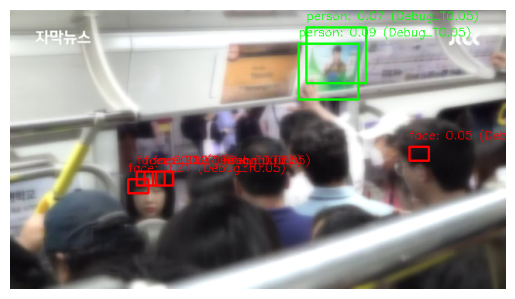

In [11]:
output_frame = analyzer.draw_detections(frame.copy(), detections)
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(output_frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [ ]:
import cv2

input_video_path = "/workspace/debug_input_video.mp4"
output_video_path = "/workspace/detected_output_video.mp4"

cap = cv2.VideoCapture(input_video_path)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

analyzer = DebugNVIDIAPeopleNet()

while True:
    ret, frame = cap.read()
    if not ret:
        break
    detections = analyzer.detect_people(frame, debug=False)
    output_frame = analyzer.draw_detections(frame.copy(), detections)
    out.write(output_frame)

cap.release()
out.release()


🚀 디버깅 NVIDIA PeopleNet 시작...
📁 모델 경로 확인: /workspace/peoplenet_vpruned_quantized_decrypted_v2.3.4/resnet34_peoplenet_int8.onnx
✅ 모델 로드 성공!
📊 입력: input_1:0, 형태: ['unk__344', 3, 544, 960]
📊 출력 개수: 2
🧪 모델 테스트 중...
✅ 테스트 성공!
   출력 0: (1, 3, 34, 60), 범위 [0.000, 0.113]
   출력 1: (1, 12, 34, 60), 범위 [-1.825, 10.853]
